# 05 · Two-Tower Neural Model

Train the dual-encoder PyTorch model, monitor loss curves, inspect learned embeddings, and build the FAISS ANN index for serving.

In [2]:
import sys

sys.path.insert(0, '..')

import ast
import time

import matplotlib.pyplot as plt
import mlflow
import pandas as pd
import seaborn as sns
import torch
from torch.utils.data import DataLoader

from config import (
    BATCH_SIZE,
    DROPOUT,
    EMBEDDING_DIM,
    FAISS_INDEX_PATH,
    HIDDEN_DIMS,
    LEARNING_RATE,
    MODELS_DIR,
    NUM_EPOCHS,
    PROCESSED_DIR,
    REPORTS_DIR,
    SPLITS_DIR,
)
from src.models.two_tower import RatingsDataset, Trainer, TwoTowerModel

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
print(f'PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}')

PyTorch 2.12.0+cpu | CUDA: False


## 1 · Load Data & Features

In [3]:
print('Loading data...')
train = pd.read_parquet(SPLITS_DIR / 'train.parquet')
val   = pd.read_parquet(SPLITS_DIR / 'val.parquet')
test  = pd.read_parquet(SPLITS_DIR / 'test.parquet')

user_features = pd.read_parquet(PROCESSED_DIR / 'user_features.parquet')
item_features = pd.read_parquet(PROCESSED_DIR / 'item_features.parquet')

# Re-parse genre_list if needed
for df in (train, val, test):
    if 'genre_list' in df.columns and isinstance(df['genre_list'].iloc[0], str):
        df['genre_list'] = df['genre_list'].apply(ast.literal_eval)

n_users  = train['user_idx'].max() + 1
n_movies = train['movie_idx'].max() + 1
print(f'Users: {n_users:,} | Movies: {n_movies:,}')

Loading data...
Users: 29,474 | Movies: 7,642


## 2 · Build PyTorch Datasets

In [4]:
print('Building datasets...')
train_ds = RatingsDataset(train, user_features, item_features)
val_ds   = RatingsDataset(val,   user_features, item_features)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE * 2,
                          shuffle=False, num_workers=0, pin_memory=False)

print(f'User feat dim  : {train_ds.user_feat_dim}')
print(f'Item feat dim  : {train_ds.item_feat_dim}')
print(f'Train batches  : {len(train_loader)}')
print(f'Val batches    : {len(val_loader)}')

Building datasets...
User feat dim  : 24
Item feat dim  : 25
Train batches  : 673
Val batches    : 37


## 3 · Model Architecture

In [5]:
model = TwoTowerModel(
    n_users=n_users,
    n_movies=n_movies,
    user_feat_dim=train_ds.user_feat_dim,
    item_feat_dim=train_ds.item_feat_dim,
    embedding_dim=EMBEDDING_DIM,
    hidden_dims=HIDDEN_DIMS,
    dropout=DROPOUT,
)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable:,}')
print()
print(model)

Total parameters    : 2,505,088
Trainable parameters: 2,505,088

TwoTowerModel(
  (user_embedding): Embedding(29474, 64)
  (movie_embedding): Embedding(7642, 64)
  (user_tower): Sequential(
    (0): Linear(in_features=88, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
  )
  (item_tower): Sequential(
    (0): Linear(in_features=89, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (6): R

## 4 · Training with MLflow

In [6]:
mlflow.set_experiment('two-tower')

with mlflow.start_run(run_name='two-tower-notebook'):
    mlflow.log_params({
        'embedding_dim': EMBEDDING_DIM,
        'hidden_dims':   str(HIDDEN_DIMS),
        'dropout':       DROPOUT,
        'lr':            LEARNING_RATE,
        'batch_size':    BATCH_SIZE,
        'n_epochs':      NUM_EPOCHS,
    })

    trainer = Trainer(model, lr=LEARNING_RATE)
    history = trainer.fit(train_loader, val_loader, n_epochs=NUM_EPOCHS)

    best = min(history, key=lambda x: x['val_rmse'])
    mlflow.log_metrics({'val_rmse': best['val_rmse'], 'val_mae': best['val_mae']})

print(f'\nBest val RMSE: {best["val_rmse"]:.4f} (epoch {best["epoch"]})')

2026/06/04 04:57:53 INFO mlflow.tracking.fluent: Experiment with name 'two-tower' does not exist. Creating a new experiment.


Training on: cpu
Epoch   1/20 | loss 0.6885 | val RMSE 0.9495 | val MAE 0.8216 | 65.9s
Epoch   2/20 | loss 0.5767 | val RMSE 0.9748 | val MAE 0.8635 | 69.5s
Epoch   3/20 | loss 0.5646 | val RMSE 1.0445 | val MAE 0.9358 | 67.8s
Epoch   4/20 | loss 0.5597 | val RMSE 1.0378 | val MAE 0.9159 | 76.8s
Epoch   5/20 | loss 0.5442 | val RMSE 1.0726 | val MAE 0.9554 | 75.7s
Epoch   6/20 | loss 0.5388 | val RMSE 0.9806 | val MAE 0.8574 | 72.2s
Epoch   7/20 | loss 0.5345 | val RMSE 1.0519 | val MAE 0.9418 | 73.2s
Epoch   8/20 | loss 0.5263 | val RMSE 1.0142 | val MAE 0.9007 | 70.4s
Epoch   9/20 | loss 0.5245 | val RMSE 1.0053 | val MAE 0.8840 | 71.8s
Epoch  10/20 | loss 0.5233 | val RMSE 1.0407 | val MAE 0.9260 | 69.4s
Epoch  11/20 | loss 0.5178 | val RMSE 1.0123 | val MAE 0.8908 | 71.9s
Epoch  12/20 | loss 0.5170 | val RMSE 1.0389 | val MAE 0.9175 | 72.1s
Epoch  13/20 | loss 0.5169 | val RMSE 1.0612 | val MAE 0.9460 | 63.7s
Epoch  14/20 | loss 0.5137 | val RMSE 1.0518 | val MAE 0.9289 | 72.0s
Epo

## 5 · Training Curves

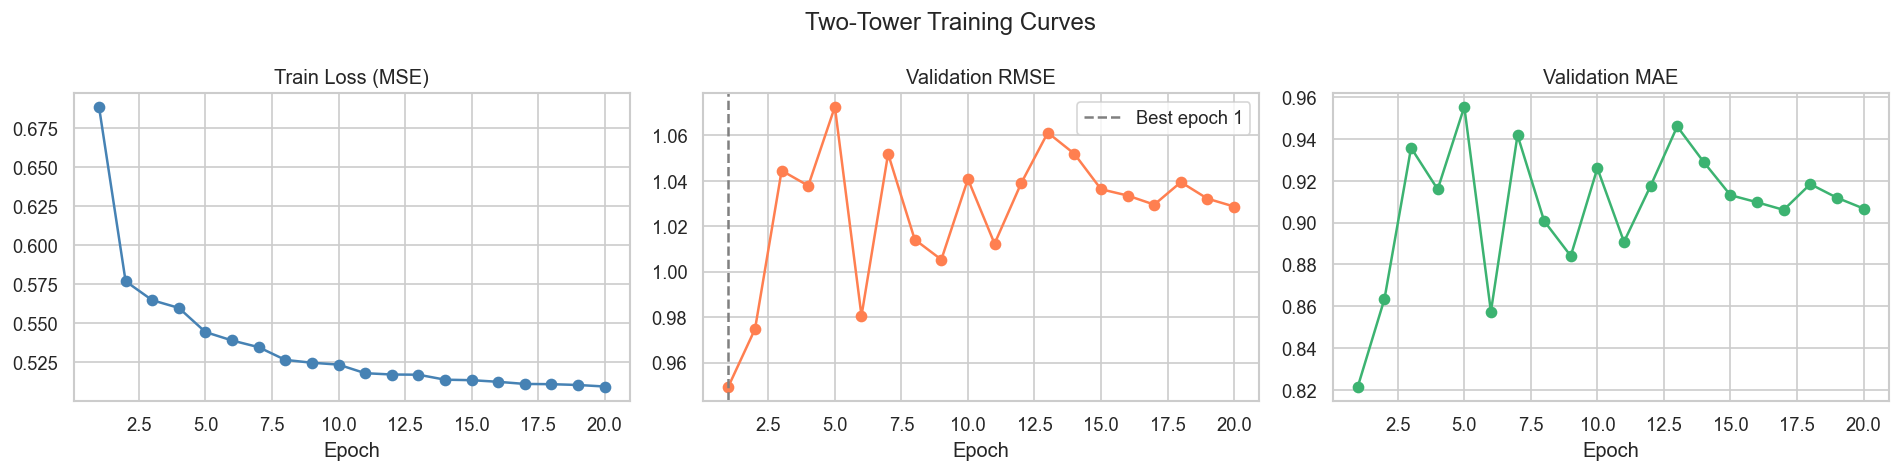

In [7]:
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(hist_df['epoch'], hist_df['train_loss'], 'o-', color='steelblue')
axes[0].set_title('Train Loss (MSE)')
axes[0].set_xlabel('Epoch')

axes[1].plot(hist_df['epoch'], hist_df['val_rmse'], 'o-', color='coral')
axes[1].axvline(best['epoch'], color='gray', linestyle='--',
                label=f'Best epoch {best["epoch"]}')
axes[1].set_title('Validation RMSE')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(hist_df['epoch'], hist_df['val_mae'], 'o-', color='mediumseagreen')
axes[2].set_title('Validation MAE')
axes[2].set_xlabel('Epoch')

plt.suptitle('Two-Tower Training Curves')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'two_tower_training_curves.png')
plt.show()

## 6 · Embedding Space Inspection

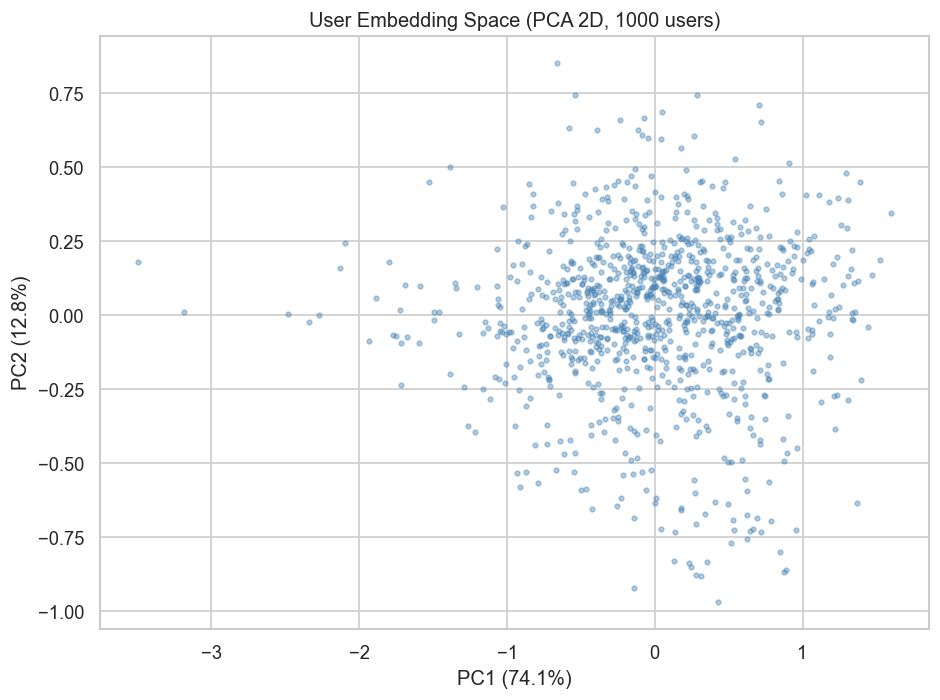

In [8]:
from sklearn.decomposition import PCA

model.eval()
device = trainer.device

# Extract user embeddings (sample 1000)
sample_users = torch.arange(min(1000, n_users))
uf_sample = torch.zeros(len(sample_users), train_ds.user_feat_dim)
for u in sample_users:
    fi = train_ds.user_feat_idx.get(u.item(), 0)
    uf_sample[u] = train_ds.user_feat_mat[fi]

with torch.no_grad():
    user_vecs = model.get_user_vector(
        sample_users.to(device), uf_sample.to(device)
    ).cpu().numpy()

pca = PCA(n_components=2, random_state=42)
u2d = pca.fit_transform(user_vecs)

plt.figure(figsize=(8, 6))
plt.scatter(u2d[:, 0], u2d[:, 1], alpha=0.4, s=8, color='steelblue')
plt.title('User Embedding Space (PCA 2D, 1000 users)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'two_tower_user_embeddings.png')
plt.show()

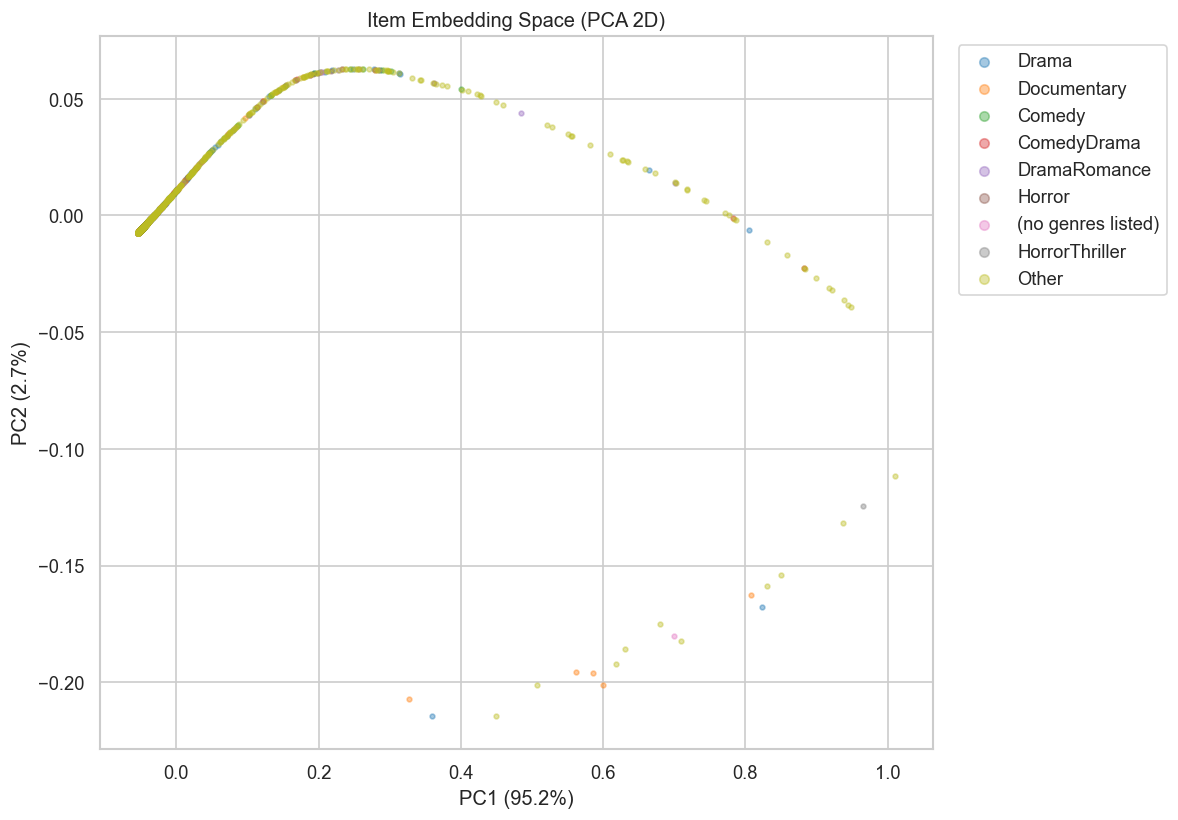

In [9]:
# Item embeddings coloured by genre
sample_items  = torch.arange(min(2000, n_movies))
if_sample     = torch.zeros(len(sample_items), train_ds.item_feat_dim)
for m in sample_items:
    fi = train_ds.item_feat_idx.get(m.item(), 0)
    if_sample[m] = train_ds.item_feat_mat[fi]

with torch.no_grad():
    item_vecs = model.get_item_vector(
        sample_items.to(device), if_sample.to(device)
    ).cpu().numpy()

pca_i = PCA(n_components=2, random_state=42)
i2d   = pca_i.fit_transform(item_vecs)

# Attach genre labels
movie_meta = train[['movie_idx', 'genre_list']].drop_duplicates('movie_idx').set_index('movie_idx')

def first_genre(gl):
    if isinstance(gl, list) and gl:
        return gl[0]
    try:
        lst = ast.literal_eval(str(gl))
        return lst[0] if lst else 'Unknown'
    except (ValueError, SyntaxError):
        return 'Unknown'

item_genres = []
for m in sample_items.numpy():
    if m in movie_meta.index:
        item_genres.append(first_genre(movie_meta.loc[m, 'genre_list']))
    else:
        item_genres.append('Unknown')

genre_series  = pd.Series(item_genres)
top_genres    = genre_series.value_counts().head(8).index.tolist()
genre_labels  = genre_series.where(genre_series.isin(top_genres), 'Other')

palette = sns.color_palette('tab10', n_colors=len(top_genres) + 1)
plt.figure(figsize=(10, 7))
for i, genre in enumerate(top_genres + ['Other']):
    mask = genre_labels == genre
    plt.scatter(i2d[mask, 0], i2d[mask, 1], alpha=0.4, s=8,
                color=palette[i], label=genre)

plt.legend(markerscale=2, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title('Item Embedding Space (PCA 2D)')
plt.xlabel(f'PC1 ({pca_i.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_i.explained_variance_ratio_[1]*100:.1f}%)')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'two_tower_item_embeddings.png')
plt.show()

## 7 · Save Model & Build FAISS Index

In [10]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
save_path = MODELS_DIR / 'two_tower.pt'
torch.save({
    'model_state':   model.state_dict(),
    'n_users':       n_users,
    'n_movies':      n_movies,
    'user_feat_dim': train_ds.user_feat_dim,
    'item_feat_dim': train_ds.item_feat_dim,
    'user_feat_idx': train_ds.user_feat_idx,
    'item_feat_idx': train_ds.item_feat_idx,
    'user_feat_mat': train_ds.user_feat_mat,
    'item_feat_mat': train_ds.item_feat_mat,
}, save_path)
print(f'Model saved → {save_path}')

Model saved → c:\Users\KIIT\OneDrive\Documents\Projects\Movie_Recommendation_System\Movie-Recommendation-System\notebooks\..\models\saved\two_tower.pt


In [11]:
# Build FAISS index
import faiss

all_items    = torch.arange(n_movies)
all_item_feat = torch.zeros(n_movies, train_ds.item_feat_dim)
for mid, fi in train_ds.item_feat_idx.items():
    if mid < n_movies:
        all_item_feat[mid] = train_ds.item_feat_mat[fi]

model.eval()
with torch.no_grad():
    all_vecs = model.get_item_vector(
        all_items.to(device), all_item_feat.to(device)
    ).cpu().numpy().astype('float32')

faiss.normalize_L2(all_vecs)
index = faiss.IndexFlatIP(all_vecs.shape[1])
index.add(all_vecs)

FAISS_INDEX_PATH.parent.mkdir(parents=True, exist_ok=True)
faiss.write_index(index, str(FAISS_INDEX_PATH))
print(f'FAISS index saved → {FAISS_INDEX_PATH} ({index.ntotal} vectors)')

FAISS index saved → c:\Users\KIIT\OneDrive\Documents\Projects\Movie_Recommendation_System\Movie-Recommendation-System\notebooks\..\models\saved\faiss_index.bin (7642 vectors)


## 8 · FAISS Retrieval Speed

In [12]:
from config import N_CANDIDATES

# Simulate 100 user queries
test_user_ids = list(train_ds.user_feat_idx.keys())[:100]

t0 = time.time()
for uid in test_user_ids:
    fi       = train_ds.user_feat_idx.get(uid, 0)
    u_feat   = train_ds.user_feat_mat[fi].unsqueeze(0)
    u_idx_t  = torch.tensor([uid])
    with torch.no_grad():
        u_vec = model.get_user_vector(u_idx_t.to(device), u_feat.to(device)).cpu().numpy().astype('float32')
    faiss.normalize_L2(u_vec)
    _, _ = index.search(u_vec, N_CANDIDATES)

elapsed = (time.time() - t0) / len(test_user_ids) * 1000
print(f'Avg FAISS retrieval time: {elapsed:.2f}ms per user ({N_CANDIDATES} candidates)')

Avg FAISS retrieval time: 0.56ms per user (100 candidates)


## 9 · Summary

In [13]:
print('=== Two-Tower Model Summary ===')
print(f'Total parameters : {trainable:,}')
print(f'Embedding dim    : {EMBEDDING_DIM}')
print(f'Hidden dims      : {HIDDEN_DIMS}')
print(f'Best epoch       : {best["epoch"]}')
print(f'Best val RMSE    : {best["val_rmse"]:.4f}')
print(f'Best val MAE     : {best["val_mae"]:.4f}')
print()
print('Key features:')
print('  - Separate user and item towers for independent scaling')
print('  - Side features augment ID embeddings (genre, year, activity)')
print('  - FAISS ANN index enables sub-millisecond retrieval at serve time')

=== Two-Tower Model Summary ===
Total parameters : 2,505,088
Embedding dim    : 64
Hidden dims      : [256, 128]
Best epoch       : 1
Best val RMSE    : 0.9495
Best val MAE     : 0.8216

Key features:
  - Separate user and item towers for independent scaling
  - Side features augment ID embeddings (genre, year, activity)
  - FAISS ANN index enables sub-millisecond retrieval at serve time
